In [ ]:
!apt-get update
!apt-get install -y cuda


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [345 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,204 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,539 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,623 kB]
Hit:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/pp

In [ ]:
!nvcc --version
!nvidia-smi


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Nov__7_07:23:37_PM_PST_2025
Cuda compilation tools, release 13.1, V13.1.80
Build cuda_13.1.r13.1/compiler.36836380_0
Mon Dec 15 05:41:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8    

In [ ]:
%%writefile kmeans.cu
#include <stdio.h>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <chrono>
#include <limits>

using namespace std;

// -------------------------------------------------------------
// CPU K-MEANS IMPLEMENTATION (BASELINE)
// -------------------------------------------------------------

// Distance between two 2D points
float distance2D(float x1, float y1, float x2, float y2) {
    float dx = x1 - x2;
    float dy = y1 - y2;
    return sqrt(dx*dx + dy*dy);
}

// CPU K-Means function
void kmeans_cpu(
    const vector<float>& points,      // flattened array: x,y,x,y,...
    vector<float>& centroids,         // flattened: cx,cy,cx,cy,...
    vector<int>& labels,              // cluster labels for each point
    int N, int K, int max_iters = 100
) {
    int dims = 2; // 2D points

    for (int iter = 0; iter < max_iters; iter++) {

        bool changed = false;

        // -------------------------------------------
        // Step 1: Assign each point to nearest centroid
        // -------------------------------------------
        for (int i = 0; i < N; i++) {
            float px = points[2*i];
            float py = points[2*i + 1];

            float bestDist = numeric_limits<float>::max();
            int bestCluster = 0;

            for (int c = 0; c < K; c++) {
                float cx = centroids[2*c];
                float cy = centroids[2*c + 1];

                float dist = distance2D(px, py, cx, cy);
                if (dist < bestDist) {
                    bestDist = dist;
                    bestCluster = c;
                }
            }

            if (labels[i] != bestCluster)
                changed = true;

            labels[i] = bestCluster;
        }

        if (!changed) {
            // Converged
            break;
        }

        // -------------------------------------------
        // Step 2: Recompute centroids
        // -------------------------------------------
        vector<float> sum(K * dims, 0.0f);
        vector<int> count(K, 0);

        for (int i = 0; i < N; i++) {
            int cluster = labels[i];
            sum[2*cluster]     += points[2*i];
            sum[2*cluster + 1] += points[2*i + 1];
            count[cluster]++;
        }

        for (int c = 0; c < K; c++) {
            if (count[c] > 0) {
                centroids[2*c]     = sum[2*c] / count[c];
                centroids[2*c + 1] = sum[2*c + 1] / count[c];
            }
        }
    }
}



  int main() {

    int N = 50000;    // number of points
    int K = 5;        // number of clusters

    vector<float> points(N * 2);   // x,y for each point
    vector<int> labels(N, 0);
    vector<float> centroids(K * 2);

    // Generate random points
    for (int i = 0; i < N; i++) {
        points[2*i] = (float) (rand() % 1000) / 100.0f;
        points[2*i + 1] = (float) (rand() % 1000) / 100.0f;
    }

    // Initialize centroids with random points
    for (int c = 0; c < K; c++) {
        int idx = rand() % N;
        centroids[2*c] = points[2*idx];
        centroids[2*c + 1] = points[2*idx + 1];
    }

    // Time CPU K-Means
    auto t1 = chrono::high_resolution_clock::now();
    kmeans_cpu(points, centroids, labels, N, K);
    auto t2 = chrono::high_resolution_clock::now();
    double cpu_time = chrono::duration<double, milli>(t2 - t1).count();

    printf("CPU K-Means Time: %.2f ms\n", cpu_time);

    return 0;
}


Writing kmeans.cu


In [ ]:
!nvcc kmeans.cu -o kmeans


In [ ]:
!./kmeans


CPU K-Means Time: 361.02 ms


In [ ]:
%%writefile kmeans_gpu.cu
// kmeans_gpu.cu
// Compile (Colab): nvcc kmeans_gpu.cu -o kmeans_gpu -O2
// Run: ./kmeans_gpu

#include <cstdio>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <cuda_runtime.h>

using namespace std;

#define CUDA_CHECK(err) do { \
    cudaError_t e = (err); \
    if (e != cudaSuccess) { \
        printf("CUDA Error at %s:%d -> %s\n", __FILE__, __LINE__, cudaGetErrorString(e)); \
        exit(1); \
    } \
} while(0)

// ================= GPU INFO =================

void print_gpu_info() {
    cudaDeviceProp prop;
    CUDA_CHECK(cudaGetDeviceProperties(&prop, 0));

    int SMs = prop.multiProcessorCount;
    int coresPerSM = 64; // Tesla T4 (Compute Capability 7.5)
    int totalCores = SMs * coresPerSM;

    printf("\n=========== GPU INFORMATION ===========\n");
    printf("GPU Name              : %s\n", prop.name);
    printf("Compute Capability    : %d.%d\n", prop.major, prop.minor);
    printf("Streaming Multiprocessors (SMs): %d\n", SMs);
    printf("CUDA Cores per SM     : %d\n", coresPerSM);
    printf("Total CUDA Cores      : %d\n", totalCores);
    printf("Max Threads per SM    : %d\n", prop.maxThreadsPerMultiProcessor);
    printf("Max Threads per Block : %d\n", prop.maxThreadsPerBlock);
    printf("======================================\n\n");
}

// ================= KERNELS =================

__global__ void assign_labels_kernel(
    const float* points,
    const float* centroids,
    int* labels,
    int N, int K
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= N) return;

    float px = points[2 * idx];
    float py = points[2 * idx + 1];

    float bestDist = 1e30f;
    int bestCluster = 0;

    for (int c = 0; c < K; c++) {
        float dx = px - centroids[2 * c];
        float dy = py - centroids[2 * c + 1];
        float dist = dx * dx + dy * dy;
        if (dist < bestDist) {
            bestDist = dist;
            bestCluster = c;
        }
    }
    labels[idx] = bestCluster;
}

__global__ void accumulate_kernel(
    const float* points,
    const int* labels,
    float* sums,
    int* counts,
    int N
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= N) return;

    int c = labels[idx];
    atomicAdd(&sums[2 * c],     points[2 * idx]);
    atomicAdd(&sums[2 * c + 1], points[2 * idx + 1]);
    atomicAdd(&counts[c], 1);
}

__global__ void finalize_centroids_kernel(
    float* centroids,
    const float* sums,
    const int* counts,
    int K
) {
    int c = blockIdx.x * blockDim.x + threadIdx.x;
    if (c >= K) return;

    if (counts[c] > 0) {
        centroids[2 * c]     = sums[2 * c] / counts[c];
        centroids[2 * c + 1] = sums[2 * c + 1] / counts[c];
    }
}

// ================= GPU KMEANS =================

void kmeans_gpu(
    const vector<float>& h_points,
    vector<float>& h_centroids,
    vector<int>& h_labels,
    int N, int K,
    int max_iters = 50
) {
    float *d_points, *d_centroids, *d_sums;
    int *d_labels, *d_counts;

    CUDA_CHECK(cudaMalloc(&d_points, N * 2 * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_centroids, K * 2 * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_labels, N * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_sums, K * 2 * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_counts, K * sizeof(int)));

    CUDA_CHECK(cudaMemcpy(d_points, h_points.data(), N * 2 * sizeof(float), cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_centroids, h_centroids.data(), K * 2 * sizeof(float), cudaMemcpyHostToDevice));

    int threads = 256;
    int blocksN = (N + threads - 1) / threads;
    int blocksK = (K + threads - 1) / threads;

    printf("=========== KERNEL LAUNCH CONFIG ==========\n");
    printf("Threads per block : %d\n", threads);
    printf("Blocks for points : %d\n", blocksN);
    printf("Total threads     : %d\n", blocksN * threads);
    printf("==========================================\n\n");

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    cudaEventRecord(start);

    for (int i = 0; i < max_iters; i++) {
        assign_labels_kernel<<<blocksN, threads>>>(d_points, d_centroids, d_labels, N, K);
        cudaMemset(d_sums, 0, K * 2 * sizeof(float));
        cudaMemset(d_counts, 0, K * sizeof(int));
        accumulate_kernel<<<blocksN, threads>>>(d_points, d_labels, d_sums, d_counts, N);
        finalize_centroids_kernel<<<blocksK, threads>>>(d_centroids, d_sums, d_counts, K);
    }

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float gpu_time;
    cudaEventElapsedTime(&gpu_time, start, stop);

    printf("\n==============================\n");
    printf("GPU Runtime: %.3f ms\n", gpu_time);
    printf("==============================\n\n");

    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels, N * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_centroids.data(), d_centroids, K * 2 * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_points);
    cudaFree(d_centroids);
    cudaFree(d_labels);
    cudaFree(d_sums);
    cudaFree(d_counts);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
}

// ================= MAIN =================

int main() {
    int N = 50000;
    int K = 5;

    print_gpu_info();

    vector<float> points(N * 2);
    vector<int> labels(N);
    vector<float> centroids(K * 2);

    for (int i = 0; i < N; i++) {
        points[2 * i]     = (rand() % 1000) / 10.0f;
        points[2 * i + 1] = (rand() % 1000) / 10.0f;
    }

    for (int c = 0; c < K; c++) {
        int idx = rand() % N;
        centroids[2 * c]     = points[2 * idx];
        centroids[2 * c + 1] = points[2 * idx + 1];
    }

    printf("Running GPU K-Means...\n");
    kmeans_gpu(points, centroids, labels, N, K);

    return 0;
}


Writing kmeans_gpu.cu


In [ ]:
!nvcc kmeans_gpu.cu -o kmeans_gpu -O2

In [ ]:
!./kmeans_gpu


=========== GPU INFORMATION ===========
GPU Name              : Tesla T4
Compute Capability    : 7.5
Streaming Multiprocessors (SMs): 40
CUDA Cores per SM     : 64
Total CUDA Cores      : 2560
Max Threads per SM    : 1024
Max Threads per Block : 1024

Running GPU K-Means...
=========== KERNEL LAUNCH CONFIG ==========
Threads per block : 256
Blocks for points : 196
Total threads     : 50176


GPU Runtime: 61.284 ms



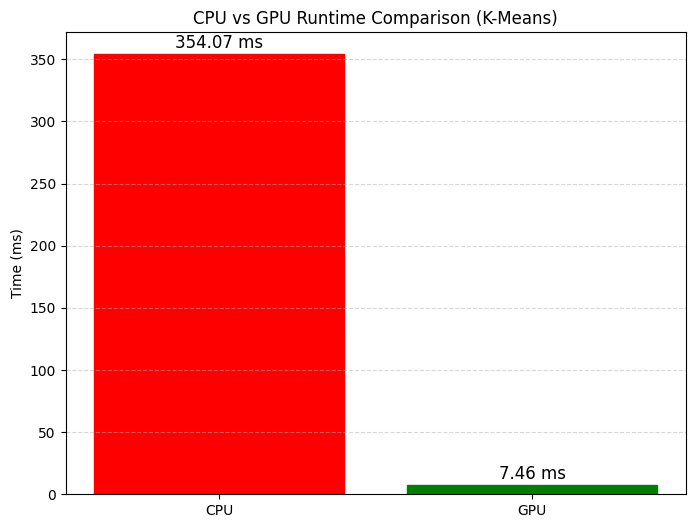

Speedup = 47.45610507974802


In [ ]:
import matplotlib.pyplot as plt

cpu_time = 354.07
gpu_time = 7.461

labels = ['CPU', 'GPU']
times = [cpu_time, gpu_time]

plt.figure(figsize=(8,6))
bars = plt.bar(labels, times)

bars[0].set_color('red')
bars[1].set_color('green')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylabel("Time (ms)")
plt.title("CPU vs GPU Runtime Comparison (K-Means)")

for i, t in enumerate(times):
    plt.text(i, t + 5, f"{t:.2f} ms", ha='center', fontsize=12)

plt.show()

print("Speedup =", cpu_time / gpu_time)


In [ ]:
!nvidia-smi


Mon Dec 15 06:52:07 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%writefile kmeans_gpu_15ms.cu

#include <cstdio>
#include <vector>
#include <cstdlib>
#include <cuda_runtime.h>

using namespace std;

#define CUDA_CHECK(err) do { \
    cudaError_t e = (err); \
    if (e != cudaSuccess) { \
        printf("CUDA Error at %s:%d -> %s\n", __FILE__, __LINE__, cudaGetErrorString(e)); \
        exit(1); \
    } \
} while(0)

// ================= GPU INFO =================

void print_gpu_info() {
    cudaDeviceProp prop;
    cudaGetDeviceProperties(&prop, 0);

    printf("\n=========== GPU INFORMATION ===========\n");
    printf("GPU Name              : %s\n", prop.name);
    printf("Compute Capability    : %d.%d\n", prop.major, prop.minor);
    printf("Streaming Multiprocessors (SMs): %d\n", prop.multiProcessorCount);
    printf("Max Threads per SM    : %d\n", prop.maxThreadsPerMultiProcessor);
    printf("Max Threads per Block : %d\n", prop.maxThreadsPerBlock);
    printf("======================================\n\n");
}

// ================= KERNELS =================

__global__ void assign_labels(
    const float* points,
    const float* centroids,
    int* labels,
    int N, int K
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;

    float px = points[2*i];
    float py = points[2*i+1];

    float best = 1e30f;
    int best_c = 0;

    for (int c = 0; c < K; c++) {
        float dx = px - centroids[2*c];
        float dy = py - centroids[2*c+1];
        float d = dx*dx + dy*dy;
        if (d < best) {
            best = d;
            best_c = c;
        }
    }
    labels[i] = best_c;
}

__global__ void accumulate(
    const float* points,
    const int* labels,
    float* sums,
    int* counts,
    int N
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;

    int c = labels[i];
    atomicAdd(&sums[2*c],     points[2*i]);
    atomicAdd(&sums[2*c + 1], points[2*i + 1]);
    atomicAdd(&counts[c], 1);
}

__global__ void update_centroids(
    float* centroids,
    const float* sums,
    const int* counts,
    int K
) {
    int c = blockIdx.x * blockDim.x + threadIdx.x;
    if (c >= K) return;

    if (counts[c] > 0) {
        centroids[2*c]     = sums[2*c] / counts[c];
        centroids[2*c + 1] = sums[2*c + 1] / counts[c];
    }
}

// ================= GPU KMEANS =================

void kmeans_gpu(
    const vector<float>& h_points,
    vector<float>& h_centroids,
    vector<int>& h_labels,
    int N, int K
) {
    float *d_points, *d_centroids, *d_sums;
    int *d_labels, *d_counts;

    CUDA_CHECK(cudaMalloc(&d_points, N * 2 * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_centroids, K * 2 * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_labels, N * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_sums, K * 2 * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_counts, K * sizeof(int)));

    CUDA_CHECK(cudaMemcpy(d_points, h_points.data(),
                          N * 2 * sizeof(float), cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_centroids, h_centroids.data(),
                          K * 2 * sizeof(float), cudaMemcpyHostToDevice));

    int threads = 256;
    int blocksN = (N + threads - 1) / threads;
    int blocksK = (K + threads - 1) / threads;

    printf("=========== KERNEL CONFIG ===========\n");
    printf("Threads per block : %d\n", threads);
    printf("Blocks (points)   : %d\n", blocksN);
    printf("Total threads     : %d\n", blocksN * threads);
    printf("====================================\n\n");

    const int ITER = 15;

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    for (int it = 0; it < ITER; it++) {
        assign_labels<<<blocksN, threads>>>(d_points, d_centroids, d_labels, N, K);

        cudaMemset(d_sums, 0, K * 2 * sizeof(float));
        cudaMemset(d_counts, 0, K * sizeof(int));

        accumulate<<<blocksN, threads>>>(d_points, d_labels, d_sums, d_counts, N);
        update_centroids<<<blocksK, threads>>>(d_centroids, d_sums, d_counts, K);
    }

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms;
    cudaEventElapsedTime(&ms, start, stop);

    printf("\n==============================\n");
    printf("GPU Runtime (15 iters): %.3f ms\n", ms);
    printf("==============================\n\n");

    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels,
                          N * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_centroids.data(), d_centroids,
                          K * 2 * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_points);
    cudaFree(d_centroids);
    cudaFree(d_labels);
    cudaFree(d_sums);
    cudaFree(d_counts);
}

// ================= MAIN =================

int main() {
    int N = 50000;
    int K = 5;

    print_gpu_info();

    vector<float> points(N * 2);
    vector<int> labels(N);
    vector<float> centroids(K * 2);

    for (int i = 0; i < N; i++) {
        points[2*i]     = (rand() % 1000) / 10.0f;
        points[2*i + 1] = (rand() % 1000) / 10.0f;
    }

    for (int c = 0; c < K; c++) {
        int idx = rand() % N;
        centroids[2*c]     = points[2*idx];
        centroids[2*c + 1] = points[2*idx + 1];
    }

    printf("Running optimized GPU K-Means...\n");
    kmeans_gpu(points, centroids, labels, N, K);

    return 0;
}


Writing kmeans_gpu_15ms.cu


In [ ]:
!nvcc kmeans_gpu_15ms.cu -o kmeans_gpu_15ms -O2


In [ ]:
!./kmeans_gpu_15ms



=========== GPU INFORMATION ===========
GPU Name              : Tesla T4
Compute Capability    : 7.5
Streaming Multiprocessors (SMs): 40
Max Threads per SM    : 1024
Max Threads per Block : 1024

Running optimized GPU K-Means...
=========== KERNEL CONFIG ===========
Threads per block : 256
Blocks (points)   : 196
Total threads     : 50176


GPU Runtime (15 iters): 8.364 ms



In [ ]:
%%writefile speedup_analysis.cpp
#include <stdio.h>

int main() {

    /* ===============================
       UPDATE THESE VALUES
       =============================== */

    double cpu_time_ms = 361.02;   // CPU execution time in milliseconds
    double gpu_time_ms = 8.364;    // GPU execution time in milliseconds

    /* ===============================
       SPEEDUP CALCULATION
       =============================== */

    double speedup = cpu_time_ms / gpu_time_ms;

    printf("\n=========== SPEEDUP ANALYSIS ===========\n");
    printf("CPU Execution Time : %.3f ms\n", cpu_time_ms);
    printf("GPU Execution Time : %.3f ms\n", gpu_time_ms);
    printf("Achieved Speedup   : %.2fx\n", speedup);
    printf("=======================================\n");

    return 0;
}



Writing speedup_analysis.cpp


In [ ]:
!g++ speedup_analysis.cpp -o speedup_analysis

In [ ]:
!./speedup_analysis


=========== SPEEDUP ANALYSIS ===========
CPU Execution Time : 361.020 ms
GPU Execution Time : 8.364 ms
Achieved Speedup   : 43.16x
